In [221]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm

# TODO:
# Use two matrices for VQ-VAE model lossy data compression
# Divide data into 4 x 4 batches
# Find embeddings using ADCS 4 x 4 batches
# scale patches into smaller scales

# Task:
# 1 patch'a - 1 pavyzdinis. Galima reguliuoti.
# Pasiimti viena event'a, nurodyti 8 x 8 patch'us ir kiekviena kvantuoti.


# Kiti darbai:
# Preprocessing acds reiksmiu. Clippint min ir max kokios gali buti.

In [222]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
BATCH_SIZE = 8
PATCH_SIZE = 8

In [223]:
# Utillities
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_ssim_value(image1: np.array, image2: np.array) -> float:
    image2_min_value = image2.min()
    image2_max_value = image2.max()
    
    ssmi_value = ssim(
        image1, 
        image2, 
        data_range=image2_max_value - image2_min_value,
        win_size=3
    )
    
    return ssmi_value

def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()
    
# def _get_4d_patch_tensor(patch: torch.tensor):
#     return torch.tensor(patch).\
#         unsqueeze(1)

def _get_vq_loss(recon_x: torch.tensor, x: torch.tensor, vq_loss: float) -> float:
    recon_loss = F.mse_loss(recon_x, x)
    return recon_loss + vq_loss

def _get_bits_from_tensor(x: torch.tensor) -> float:
    return (x.element_size() * x.numel()) * 8

# def _get_compression_ratio(a: torch.tensor, b: torch.tensor, precision: int) -> float:
#     a_bits = _get_bits_from_tensor(a)
#     b_bits = _get_bits_from_tensor(b)
    
#     print(f"a BITS: {a_bits}")
#     print(f"a dtype: {a.dtype}")
    
#     print(f"b BITS: {b_bits}")
#     print(f"b dtype: {b.dtype}")
    
#     return np.round(a_bits / b_bits, precision)

def event_hits_metrics(events: PixelDigiEvent, reconstructed_events: PixelDigiEvent) -> None:
    return {
        "rmse" : compare_matching_hits(events, reconstructed_events, metric='rmse'),
        'mae': compare_matching_hits(events, reconstructed_events, metric='mae'),
        'mismatch_ratio': compare_matching_hits(events, reconstructed_events, metric='mismatch_ratio'),
        'reco_precision_recall' : compare_hit_presence(events, reconstructed_events)
    }

# Based on formula 2.2, "Comparative study of compression algorithms on time series data for IoT devices"
def _get_patch_bits(num_embeddings: int, embedding_size: int) -> float:
    bits_per_index = np.ceil(np.log2(num_embeddings))
    total_encoding_bits = embedding_size * bits_per_index
    return total_encoding_bits

def _get_compression_ratio(image: torch.tensor, num_embeddings: int, embedding_size: int) -> float:
    image_bits = _get_bits_from_tensor(image)
    result = image_bits / _get_patch_bits(num_embeddings, embedding_size)
    return result

In [224]:
# Moduliai ir ju savybes aprasomos pixel_modules json'uose
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:03<00:00, 275.85it/s]


In [225]:
# Params
batch_size = 64
learning_rate = 1e-5
# num_epochs = 80
num_epochs = 80
channels = 1
latent_dim = 32
num_embeddings = 128  # Number of vectors in the codebook
beta = 0.21 # Beta, the commitment loss weight for moving vectors closer to the cendroid
num_residual_hiddens = 3
num_residual_layers = 2

decay = 0.98
vq_epsilon = 1e-5

LOG_EVERY = 10


In [226]:
# Selecting GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Applying seed for reproducability
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

device

device(type='cuda')

In [227]:
event_train = events_train[:SELECTED_EVENTS][0]


In [228]:
events_train_display = iter(events_train)

In [229]:
event_train_patches = event_hits_to_patches(event_train, patch_size=PATCH_SIZE)
event_train_patches_adcs = event_train_patches.as_array()
event_train_patches_adcs.shape

(15857, 64)

In [230]:
event_train_patches_adcs[0].shape

(64,)

In [231]:
len(event_train_patches_adcs)

15857

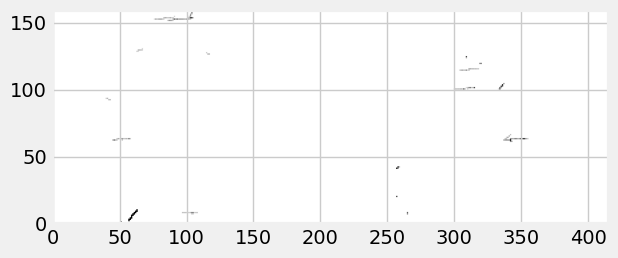

In [232]:
# plt.figure(figsize=(12, 6))
show_image(event_train)

In [233]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
        ]
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [234]:
# X_patches_batches = torch.tensor(X_patches_batches).unsqueeze(1).float()
transform = transforms.Compose([
    transforms.ToTensor()
    # transforms.Normalize(mean=[0.5], std=[0.5])    
])
event_dataset = PixelPatchesDataset(event_train)

train_loader = DataLoader(
    dataset=event_dataset, 
    batch_size=batch_size
)

# Data preprocessing
events_test_loaders = []

for event_test in events_test:
    event_dataset = PixelPatchesDataset(event_test, transform)

    event_test_loader = DataLoader(
        dataset=event_dataset, 
        batch_size=batch_size
    )
    events_test_loaders.append(event_test_loader)

In [235]:
data_sample = next(iter(train_loader))
data_sample.shape

torch.Size([64, 8, 8])

In [236]:
data_sample[0].dtype

torch.uint8

In [237]:
# next(iter(train_loader))

In [238]:
# patch_tensor = _get_4d_patch_tensor(data_sample[0])
# patch_tensor.shape

In [239]:
len(train_loader)

248

In [240]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost, decay, epsilon):
        super().__init__()

        self._num_embeddings = num_embeddings
        self._embedding_dim = embedding_dim

        self._embedding = nn.Embedding(self._num_embeddings, self._embedding_dim)
        self._embedding.weight.data.normal_()
        self._commitment_cost = commitment_cost

        self.register_buffer('_ema_cluster_size', torch.zeros(num_embeddings))
        self.register_buffer("_ema_w", self._embedding.weight.data.clone())
        
        self._decay = decay
        self._device = device
        self._epsilon = epsilon

    def forward(self, inputs):
        """
        Connects the module to some inputs.

        Args:
            inputs: Tensor, final dimension must be equal to embedding_dim. All other
                leading dimensions will be flattened and treated as a large batch.
        
        Returns:
            loss: Tensor containing the loss to optimize.
            quantize: Tensor containing the quantized version of the input.
            perplexity: Tensor containing the perplexity of the encodings.
            encodings: Tensor containing the discrete encodings, ie which element
                of the quantized space each input element was mapped to.
            distances
        """

        # Convert inputs from BCHW -> BHWC
        # (1, 0, 2, 3
        inputs = inputs.permute(0, 2, 3, 1).contiguous()
        
        input_shape = inputs.shape
        
        # Flatten input
        flat_input = inputs.view(-1, self._embedding_dim)
        
        # Compute distances between encoded audio frames and embedding vectors
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True) 
                    + torch.sum(self._embedding.weight**2, dim=1)
                    - 2 * torch.matmul(flat_input, self._embedding.weight.t()))

        """
        encoding_indices: Tensor containing the discrete encoding indices, ie
        which element of the quantized space each input element was mapped to.
        """
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self._num_embeddings, dtype=torch.float).to(self._device)
        encodings.scatter_(1, encoding_indices, 1)


        # Sample nearest embedding
        # Use EMA to update the embedding vectors
        if self.training:
            with torch.no_grad():
                # EMA cluster size
                
                # controlls how smoothly the weights change
                self._ema_cluster_size.mul_(self._decay).add_(
                    encodings.sum(0), alpha=1 - self._decay
                )

                # EMA embedding weights
                dw = torch.matmul(encodings.t(), flat_input)  # [K, C]
                self._ema_w.mul_(self._decay).add_(dw, alpha=1 - self._decay)

                # Laplace smoothing
                n = self._ema_cluster_size.sum()
                smoothed_cluster_size = (
                    (self._ema_cluster_size + self._epsilon)
                    / (n + self._num_embeddings * self._epsilon)
                    * n
                )

                self._embedding.weight.data.copy_(
                    self._ema_w / smoothed_cluster_size.unsqueeze(1)
                )

        
        avg_probs = torch.mean(encodings, dim=0)
        # Quantize and unflatten
        quantized = torch.matmul(encodings, self._embedding.weight).view(input_shape)
        # TODO: Check if the more readable self._embedding.weight.index_select(dim=1, index=encoding_indices) works better
        # Loss
        e_latent_loss = torch.mean((quantized.detach() - inputs)**2)
        commitment_loss = self._commitment_cost * e_latent_loss        
        quantized = inputs + (quantized - inputs).detach()
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        """
        The perplexity a useful value to track during training.
        It indicates how many codes are 'active' on average.
        """

        quantized = quantized.view(input_shape)  # [B, H, W, C]
        
        # print(quantized.shape)
        
        quantized = quantized.permute(0, 3, 1, 2).contiguous()
        # quantized = quantized.contiguous()
        # Convert quantized from BHWC -> BCHW
        return (
            quantized, 
            commitment_loss, 
            perplexity,
            encoding_indices
        )

In [241]:
class Residual(nn.Module):
    """
    Residual Convolutional Layer
    """

    def __init__(self, in_channels, num_residual_hiddens):
        """
        initialize residual CNN layer

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_hiddens number: Number of residual hiddens
        """
        super(Residual, self).__init__()
        self._block = nn.Sequential(
            nn.ReLU(True),
            # C: 3 -> residual hidden
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=num_residual_hiddens,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.ReLU(True),
            # C: resiual hidden -> out_hidden
            nn.Conv2d(
                in_channels=num_residual_hiddens,
                out_channels=in_channels,
                kernel_size=1,
                stride=1,
                bias=False,
            ),
        )

    def forward(self, x):
        """
        Residual layer

        :param x numpy.ndarray: Input image
        """
        return x + self._block(x)  # residual output


class ResidualStack(nn.Module):
    """
    Residual Convolution Stack
    """

    def __init__(
        self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens
    ):
        """
        initialize residual stack

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_layers number: Number of residual layers in stack
        :param num_residual_hiddens number: Number of hidden residual channels
        """
        super(ResidualStack, self).__init__()
        self._num_residual_layers = num_residual_layers
        self._layers = nn.ModuleList(
            [
                Residual(in_channels, num_hiddens, num_residual_hiddens)
                for _ in range(self._num_residual_layers)
            ]
        )

    def forward(self, x):
        """
        Apply residual stack

        :param x numpy.ndarray: Input image
        """
        # Apply all residual layers in stack
        for i in range(self._num_residual_layers):
            x = self._layers[i](x)
        return F.relu(x)

In [242]:
# Updates
# Batch normalization reduced value shift by subtracting mean and deviding variance
# Also uses learnable parameters beta


class VQVAE(nn.Module):
    def __init__(self, hidden_channels: int, kernel_size: int, debug: bool=False):
        super(VQVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels * 2, kernel_size=kernel_size, stride=2),
            nn.ReLU(),
            nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=kernel_size, stride=2),
            nn.ReLU(),
            # Residual(hidden_channels, num_residual_layers),
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1),
            nn.ReLU(),
            #  nn.BatchNorm2d(latent_dim)
        )
        self.debug = debug

        # Vector Quantization
        self.vq_layer = VQEmbedding(
            num_embeddings, 
            latent_dim, 
            beta, 
            decay=decay, 
            epsilon=vq_epsilon
        )

        # Decoder
        self.decoder = nn.Sequential(
            # nn.GroupNorm(num_groups=8, num_channels=16),
            nn.ReLU(),
            # nn.BatchNorm2d(latent_dim),
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=1),
            nn.ReLU(),
            # Residual(hidden_channels, num_residual_layers),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels * 2, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_channels * 2, channels, kernel_size=kernel_size, stride=2),
            nn.Sigmoid()
        )
        self.debug = debug

    def forward(self, x):
        z_e = self.encoder(x)        
        
        # print(f"Compressed shape: {z_e.shape}")
        
        z_q, vq_loss, perplexity, _ = self.vq_layer(z_e)
        
        # print(z_q.shape)
        
        # bit_size = encodings.element_size() * 8
        # print(f"Calculated Codebook size: {bit_size} bits")
    
        x_recon = self.decoder(z_q)    
        
        return (
           x_recon, 
           vq_loss, 
           perplexity, 
           z_q
        )

In [243]:
model = VQVAE(
    hidden_channels = 8,
    kernel_size = 2
).to(device)


In [244]:
optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 248/248 [00:00<00:00, 851.33it/s, Loss=433]   


Average perplexity: 1.947920015742702
Epoch [1/80] Average Loss: 568.0887
Before compression
Before: (64, 8, 8)


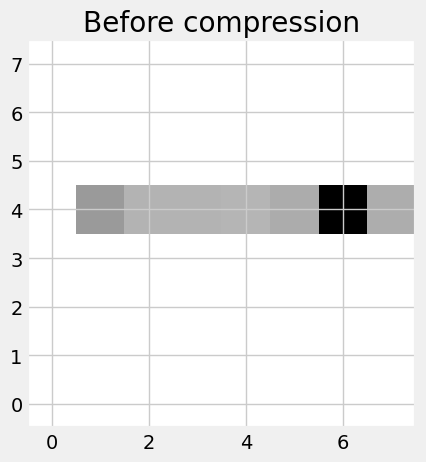

After: (1, 8, 8)
After compression


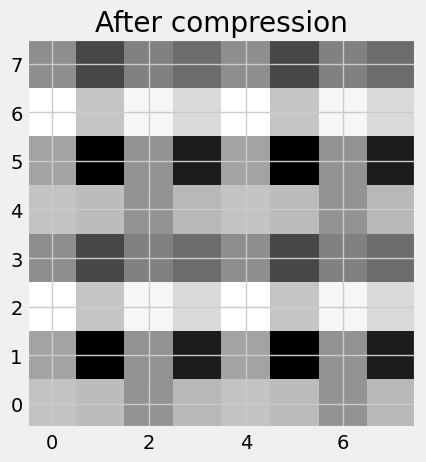

Epoch 2/80: 100%|██████████| 248/248 [00:00<00:00, 806.36it/s, Loss=433]   


Average perplexity: 2.0413574350457036
Epoch [2/80] Average Loss: 567.9200


Epoch 3/80: 100%|██████████| 248/248 [00:00<00:00, 792.68it/s, Loss=433]   


Average perplexity: 3.082962374052694
Epoch [3/80] Average Loss: 567.7563


Epoch 4/80: 100%|██████████| 248/248 [00:00<00:00, 800.80it/s, Loss=433]   


...

Average perplexity: 3.49933815483124
Epoch [9/80] Average Loss: 566.7811


Epoch 10/80: 100%|██████████| 248/248 [00:00<00:00, 800.20it/s, Loss=431]   


Average perplexity: 3.591443348315454
Epoch [10/80] Average Loss: 566.5461


Epoch 11/80: 100%|██████████| 248/248 [00:00<00:00, 833.57it/s, Loss=431]   


Average perplexity: 3.610736769053244
Epoch [11/80] Average Loss: 566.2994
Before compression
Before: (64, 8, 8)


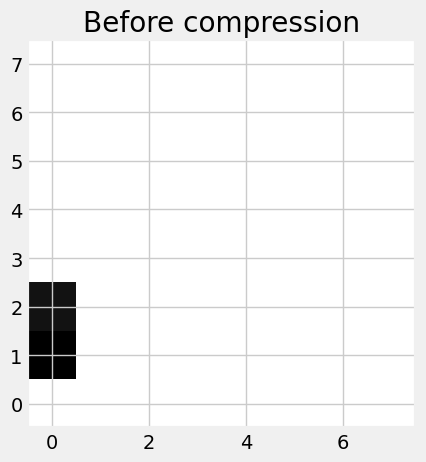

After: (1, 8, 8)
After compression


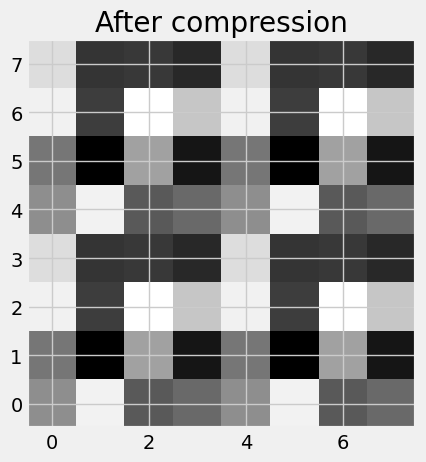

Epoch 12/80: 100%|██████████| 248/248 [00:00<00:00, 843.51it/s, Loss=431]   


Average perplexity: 3.592108819753893
Epoch [12/80] Average Loss: 566.0553


Epoch 13/80: 100%|██████████| 248/248 [00:00<00:00, 845.68it/s, Loss=431]   


Average perplexity: 3.57364873924563
Epoch [13/80] Average Loss: 565.8130


Epoch 14/80: 100%|██████████| 248/248 [00:00<00:00, 832.16it/s, Loss=431]   


...

Average perplexity: 3.6366625687768384
Epoch [19/80] Average Loss: 564.8598


Epoch 20/80: 100%|██████████| 248/248 [00:00<00:00, 839.29it/s, Loss=430]   


Average perplexity: 3.6390563499542976
Epoch [20/80] Average Loss: 564.7703


Epoch 21/80: 100%|██████████| 248/248 [00:00<00:00, 829.75it/s, Loss=430]   


Average perplexity: 3.637611100750585
Epoch [21/80] Average Loss: 564.6998
Before compression
Before: (64, 8, 8)


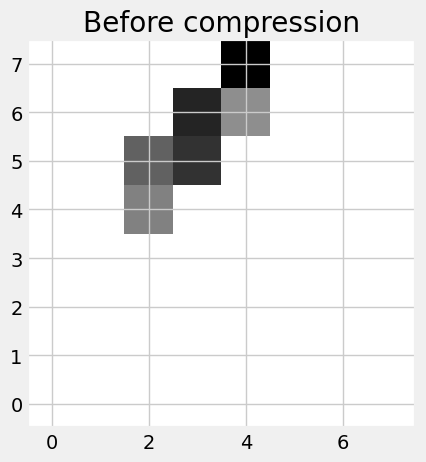

After: (1, 8, 8)
After compression


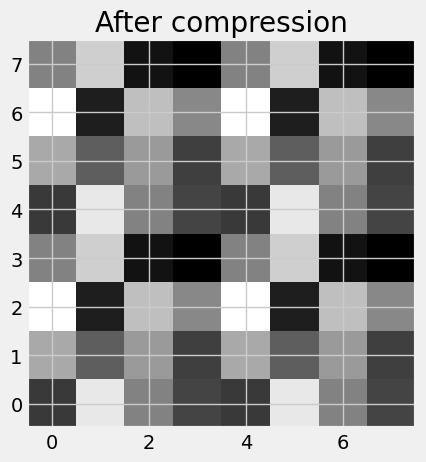

Epoch 22/80: 100%|██████████| 248/248 [00:00<00:00, 859.62it/s, Loss=430]   


Average perplexity: 3.630416380782281
Epoch [22/80] Average Loss: 564.6439


Epoch 23/80: 100%|██████████| 248/248 [00:00<00:00, 868.99it/s, Loss=430]   


Average perplexity: 3.6223278920496664
Epoch [23/80] Average Loss: 564.5977


Epoch 24/80: 100%|██████████| 248/248 [00:00<00:00, 861.85it/s, Loss=430]   


...

Average perplexity: 3.6923808743876796
Epoch [29/80] Average Loss: 564.3997


Epoch 30/80: 100%|██████████| 248/248 [00:00<00:00, 818.88it/s, Loss=430]   


Average perplexity: 3.7224042204118546
Epoch [30/80] Average Loss: 564.3754


Epoch 31/80: 100%|██████████| 248/248 [00:00<00:00, 811.80it/s, Loss=430]   


Average perplexity: 3.743690256149538
Epoch [31/80] Average Loss: 564.3538
Before compression
Before: (64, 8, 8)


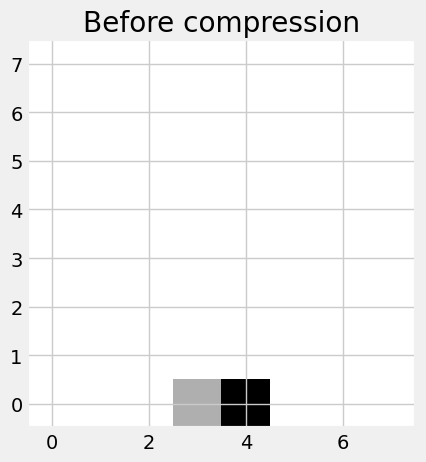

After: (1, 8, 8)
After compression


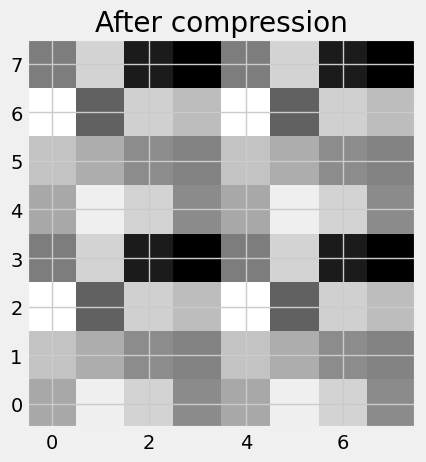

Epoch 32/80: 100%|██████████| 248/248 [00:00<00:00, 839.67it/s, Loss=430]   


Average perplexity: 3.753190335727507
Epoch [32/80] Average Loss: 564.3348


Epoch 33/80: 100%|██████████| 248/248 [00:00<00:00, 852.05it/s, Loss=430]   


Average perplexity: 3.760202169418335
Epoch [33/80] Average Loss: 564.3174


Epoch 34/80: 100%|██████████| 248/248 [00:00<00:00, 856.88it/s, Loss=430]   


...

Average perplexity: 3.7494409632298256
Epoch [39/80] Average Loss: 564.2374


Epoch 40/80: 100%|██████████| 248/248 [00:00<00:00, 826.38it/s, Loss=430]   


Average perplexity: 3.743803777040974
Epoch [40/80] Average Loss: 564.2268


Epoch 41/80: 100%|██████████| 248/248 [00:00<00:00, 843.11it/s, Loss=430]   


Average perplexity: 3.744193958659326
Epoch [41/80] Average Loss: 564.2162
Before compression
Before: (64, 8, 8)


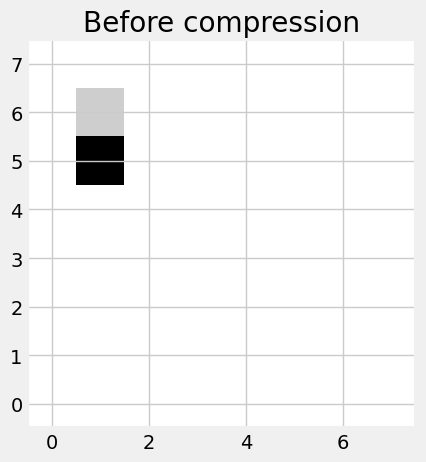

After: (1, 8, 8)
After compression


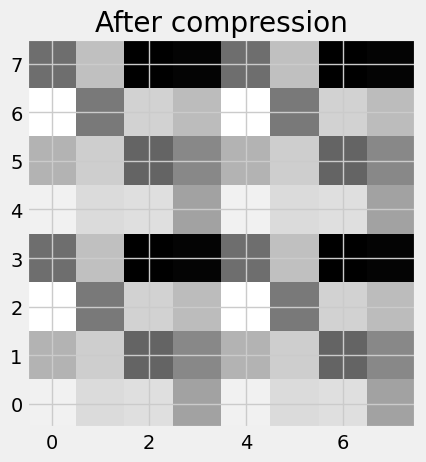

Epoch 42/80: 100%|██████████| 248/248 [00:00<00:00, 838.44it/s, Loss=429]   


Average perplexity: 3.74064086617962
Epoch [42/80] Average Loss: 564.2052


Epoch 43/80: 100%|██████████| 248/248 [00:00<00:00, 803.63it/s, Loss=429]   


Average perplexity: 3.7327189935791876
Epoch [43/80] Average Loss: 564.1953


Epoch 44/80: 100%|██████████| 248/248 [00:00<00:00, 822.24it/s, Loss=429]   


...

Average perplexity: 3.7472354404387938
Epoch [49/80] Average Loss: 564.1493


Epoch 50/80: 100%|██████████| 248/248 [00:00<00:00, 815.85it/s, Loss=429]   


Average perplexity: 3.748293827618322
Epoch [50/80] Average Loss: 564.1437


Epoch 51/80: 100%|██████████| 248/248 [00:00<00:00, 818.51it/s, Loss=429]   


Average perplexity: 3.747707862046457
Epoch [51/80] Average Loss: 564.1387
Before compression
Before: (64, 8, 8)


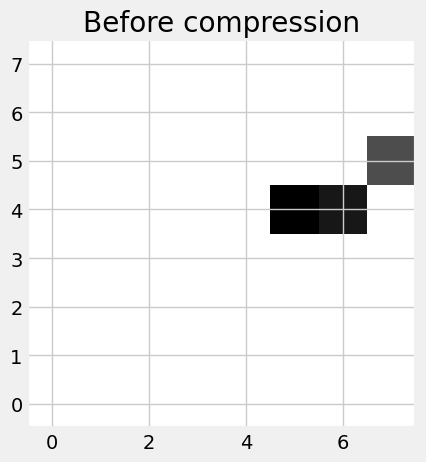

After: (1, 8, 8)
After compression


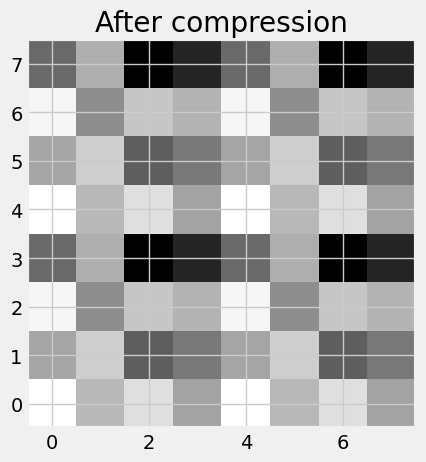

Epoch 52/80: 100%|██████████| 248/248 [00:00<00:00, 816.26it/s, Loss=429]   


Average perplexity: 3.746900349855423
Epoch [52/80] Average Loss: 564.1340


Epoch 53/80: 100%|██████████| 248/248 [00:00<00:00, 793.25it/s, Loss=429]   


Average perplexity: 3.747071954511827
Epoch [53/80] Average Loss: 564.1295


Epoch 54/80: 100%|██████████| 248/248 [00:00<00:00, 821.22it/s, Loss=429]   


...

Average perplexity: 3.74452285035964
Epoch [59/80] Average Loss: 564.1074


Epoch 60/80: 100%|██████████| 248/248 [00:00<00:00, 751.47it/s, Loss=429]   


Average perplexity: 3.7446067121721085
Epoch [60/80] Average Loss: 564.1043


Epoch 61/80: 100%|██████████| 248/248 [00:00<00:00, 781.71it/s, Loss=429]   


Average perplexity: 3.742872062229341
Epoch [61/80] Average Loss: 564.1013
Before compression
Before: (64, 8, 8)


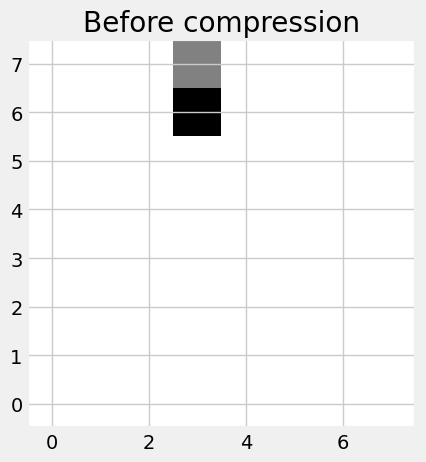

After: (1, 8, 8)
After compression


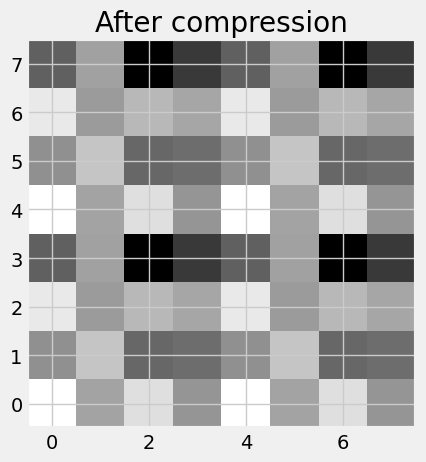

Epoch 62/80: 100%|██████████| 248/248 [00:00<00:00, 782.36it/s, Loss=429]   


Average perplexity: 3.7420213962754896
Epoch [62/80] Average Loss: 564.0984


Epoch 63/80: 100%|██████████| 248/248 [00:00<00:00, 831.13it/s, Loss=429]   


Average perplexity: 3.740968216811457
Epoch [63/80] Average Loss: 564.0957


Epoch 64/80: 100%|██████████| 248/248 [00:00<00:00, 818.75it/s, Loss=429]   


...

Average perplexity: 3.735598943887218
Epoch [69/80] Average Loss: 564.0808


Epoch 70/80: 100%|██████████| 248/248 [00:00<00:00, 843.96it/s, Loss=429]   


Average perplexity: 3.7337926347409525
Epoch [70/80] Average Loss: 564.0785


Epoch 71/80: 100%|██████████| 248/248 [00:00<00:00, 847.94it/s, Loss=429]   


Average perplexity: 3.731190091179263
Epoch [71/80] Average Loss: 564.0762
Before compression
Before: (64, 8, 8)


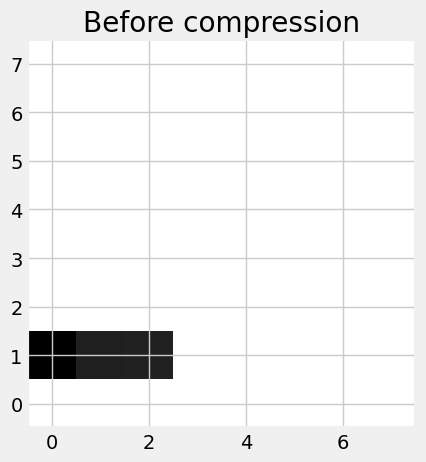

After: (1, 8, 8)
After compression


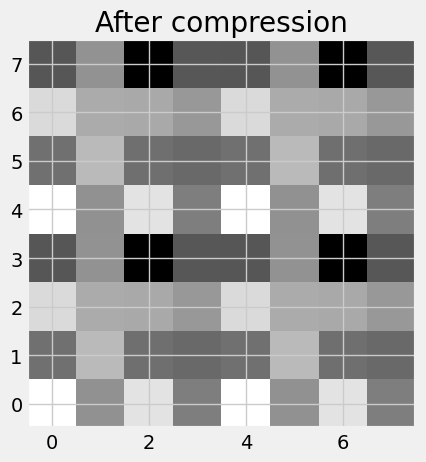

Epoch 72/80: 100%|██████████| 248/248 [00:00<00:00, 839.77it/s, Loss=429]   


Average perplexity: 3.7303166293328807
Epoch [72/80] Average Loss: 564.0741


Epoch 73/80: 100%|██████████| 248/248 [00:00<00:00, 846.76it/s, Loss=429]   


Average perplexity: 3.7294989583953733
Epoch [73/80] Average Loss: 564.0720


Epoch 74/80: 100%|██████████| 248/248 [00:00<00:00, 792.89it/s, Loss=429]   


...

Average perplexity: 3.725087572490015
Epoch [78/80] Average Loss: 564.0629


Epoch 79/80: 100%|██████████| 248/248 [00:00<00:00, 784.98it/s, Loss=429]   


Average perplexity: 3.7249329455437197
Epoch [79/80] Average Loss: 564.0613


Epoch 80/80: 100%|██████████| 248/248 [00:00<00:00, 823.47it/s, Loss=429]   

Average perplexity: 3.7252875537641588
Epoch [80/80] Average Loss: 564.0597


In [245]:
# loss
average_loss_values = []
# ssim
ssim_values = []

# perplexity
perplexity_values = []

# Cutting after certain epochs
# scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size=30,   # every 30 epochs
#     gamma=0.01       # multiply LR by 0.1
# )

# num_epochs = 20
idx_validation = 0
patch_test_cursor = iter(events_test_loaders[0])

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    perplexity_per_epoch = 0

    # Use tqdm for the progress bar
    progress_bar = tqdm(
        enumerate(train_loader), 
        total=len(train_loader), 
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    display = False
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        X_adcs = X_adcs.to(device)
        X_adcs = X_adcs.float()
        
        
        # X_noisy = X_adcs.float() + 0.01 + torch.randn_like(X_adcs)
        # X_noisy = X_noisy.to(device).permute(0, 1, 2, 3)
        X_adcs_tr = X_adcs.unsqueeze(1).permute(0, 1, 2, 3)
        
        # print(f"Inputing to model: {str(X_adcs.shape)}")
        
        (
            recon_patch, 
            vq_loss, 
            perplexity, 
            _
        ) = model(
           X_adcs_tr
        )
        recon_patch = recon_patch.float().to(device)      
        
        loss = _get_vq_loss(recon_patch, X_adcs_tr, vq_loss)
        loss.backward()
        train_loss += loss.item()
        perplexity_per_epoch += perplexity.item()
        
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
    # Saving epoch  statistics
    perplexity_average = perplexity_per_epoch / len(train_loader)
    print(f"Average perplexity: {perplexity_average}")
    
    perplexity_values.append(perplexity_average)    
    avg_loss = train_loss / len(train_loader)
    average_loss_values.append(avg_loss)
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
    
    if epoch % LOG_EVERY == 0:
        with torch.no_grad():            
            # selecting events before reconstruction using one test loader as validation
            patch_test = next(patch_test_cursor) 
            patch_test = patch_test.to(device)           
            print("Before compression")
            
            patch_test_ts = _tensor_to_numpy(
                patch_test.squeeze(1)
            )
            
            print(f"Before: {patch_test_ts.shape}")
            
            plot_patch(patch_test_ts[0], "Before compression")
            
            (
                recon_patch, 
                _, 
                perplexity, 
                _                
            ) = model(patch_test)
            
            recon_patch_np = _tensor_to_numpy(
                recon_patch[0]
            )
            print(f"After: {recon_patch_np.shape}")
            print("After compression")
            
            plot_patch(recon_patch_np[0], "After compression")
        

In [246]:
# TODO: Try fitting all patch'es to VQ-VAE, get calculated bits of patches and total hits per event.
# TODO: Calculate ratio before how many bits were used per patch and after compression how many bits were 
# used per patch 

In [247]:
# Test model with unseen data
events_test_patches_adcs = [
    event_hits_to_patches(event, PATCH_SIZE).as_array()
    for event in events_test[:SELECTED_EVENTS]
]

events_test_patches = [
    event_hits_to_patches(event, PATCH_SIZE)
    for event in events_test[:SELECTED_EVENTS]
]
print(f"Events test: {len(events_test_patches_adcs)}")
print(f"Event patches: {len(events_test_patches[0])}")


Events test: 1
Event patches: 8452


In [248]:
X_test_patch = events_test_patches_adcs[0][0]
X_test = torch.tensor(X_test_patch).to(device).float()
X_test = X_test.reshape(
    PATCH_SIZE, 
    PATCH_SIZE
).unsqueeze(1).permute(1, 0, 2).unsqueeze(1)


In [249]:
X_test.shape

torch.Size([1, 1, 8, 8])

In [250]:
model.eval()

print("Compression quality measurements")

with torch.no_grad():
    model = VQVAE(
        hidden_channels = 3,
        kernel_size = 2    
    ).to(device)
    X_test = X_test.permute(1, 0, 2, 3)
    print(X_test.shape)
    z = model.encoder(X_test)
    z, vq_loss, perplexity, encodings = model.vq_layer(z)
    print(f"Latent shape: {z.shape}")
    
    used_codes = torch.unique(encodings)
    num_used = used_codes.numel()
    
    print(f"Codebook unique encodings:{len(used_codes)}")
    print(encodings.shape)
    print(encodings.unique())
    
    codebook = model.vq_layer._embedding.weight
    codebook_size = codebook.element_size() * codebook.numel()
    
    print(f"Codebook size: {len(used_codes)}")
    
    X_test_bits = _get_bits_from_tensor(X_test)
    
    compression_ratio = _get_compression_ratio(X_test, num_embeddings, encodings.numel())
    print(f"Compression ratio: {compression_ratio}")
    
    patch_bits = _get_patch_bits(num_embeddings, encodings.numel())
    print(f"Tensor bits: {X_test_bits}")
    print(f"Used patch bits: {patch_bits}")
    
    # TOtal codebook size
    print(f"Embedding size: {encodings.numel()}")
    
    # print(encodings.shape)
    

Compression quality measurements
torch.Size([1, 1, 8, 8])
Latent shape: torch.Size([1, 32, 2, 2])
Codebook unique encodings:3
torch.Size([4, 1])
tensor([ 28,  90, 115], device='cuda:0')
Codebook size: 3
Compression ratio: 73.14285714285714
Tensor bits: 2048
Used patch bits: 28.0
Embedding size: 4


In [251]:
events_test[0].det_ids

array([303042564, 303042564, 303042564, ..., 353339396, 353339396,
       353339396], shape=(24791,), dtype=int32)

/tmp/ipykernel_3521379/2342257702.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Average reconstruction loss over epochs values over epochs


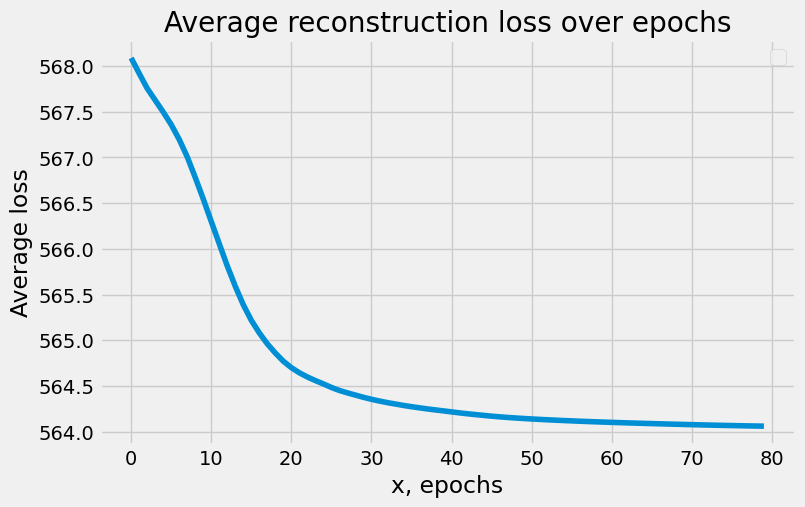

In [252]:
plot_metric_results(
    average_loss_values, 
    list(range(num_epochs)), 
    "Average loss", 
    "Average reconstruction loss over epochs",
    "x, epochs"
)

In [253]:
torch.save(model.state_dict(), "vq_vae_pileup.pth")

In [254]:
# TODO: change debug for option change event_hit_test count
# def _get_reshape_tensor(patch_flatten: np.array) -> torch.tensor:
#     patch = patch_flatten.reshape(PATCH_SIZE, PATCH_SIZE)
#     patch_tensor_ini = torch.tensor(patch)
#     # patch_tensor = patch_tensor_ini.unsqueeze(1).unsqueeze(1).transpose(0, 2)
#     patch_tensor = patch_tensor_ini.unsqueeze(1)
#     patch_tensor = patch_tensor.float()
#     patch_tensor = patch_tensor.to(device)
#     return patch_tensor

# events_test_patches_tensors = []
# for event_test_patches_adcs in events_test_patches_adcs:
#     event_test_patches_tensors = list(map(_get_reshape_tensor, event_test_patches_adcs))
#     event_test_patch_first = event_test_patches_tensors[0]
#     print(f"DEBUG: first event shape: {event_test_patch_first.shape}")
    
#     events_test_patches_tensors.append(event_test_patches_tensors)

In [255]:
# len(event_test_patches_tensors)

Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)


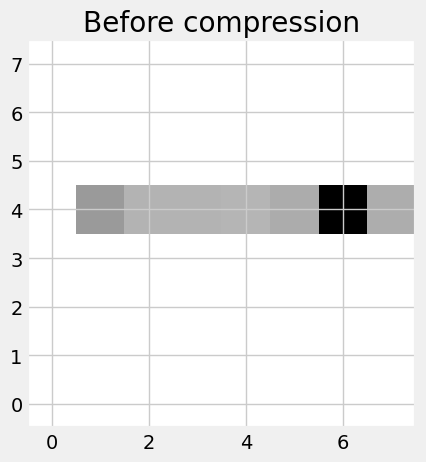

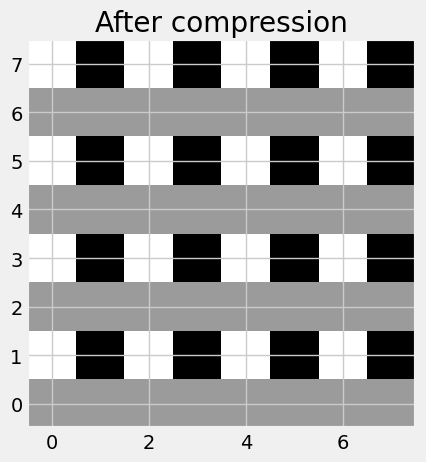

Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)


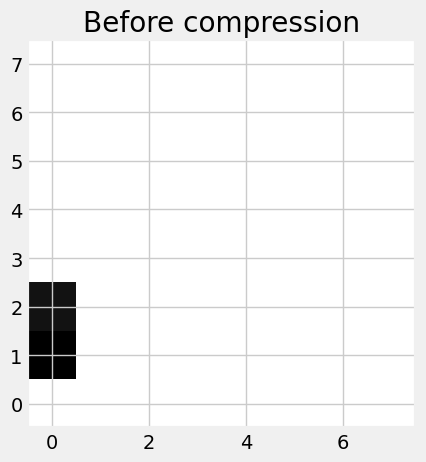

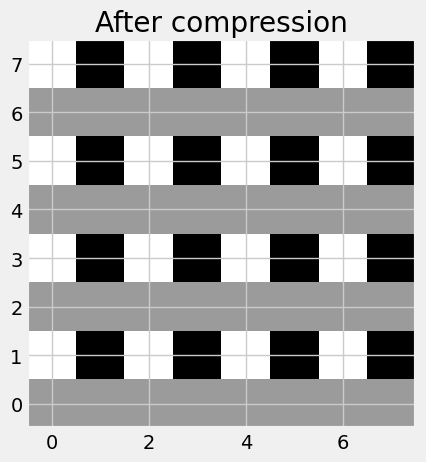

Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch comp

In [256]:
# Performing test on unseen data
plot_patches_debug = 2
plotted_patches = 0
fill_value = 0
decompressed_events = []
T_SIMILAR = 0.7
T_DISSIMILAR = 0
T_IDENTICAL = 0.9
T_CODEBOOK = 2

model.load_state_dict(torch.load("vq_vae_pileup.pth"))
model = model.to(device)
# model.eval() 

# compressing patches
events_test_patches = [
    event_hits_to_patches(event, PATCH_SIZE)
    for event in events_test
]

# compressing / decompressing each event patch adcs
for (i, event_test_loader) in enumerate(events_test_loaders):
    event_adcs_merged = []
    
    for (j, event_patch) in enumerate(event_test_loader):
        with torch.no_grad():
            event_patch = event_patch.to(device)
            (
                recon_patch, 
                _, 
                _, 
                z_q
            ) = model(event_patch)
            
            # Reconstructed adcs
            patch_original = _tensor_to_numpy(
                event_patch.squeeze(1)
            )
            
            recon_patch_np = _tensor_to_numpy(
                recon_patch.squeeze(1)
            )
            
            # compression_ratio = _get_compression_ratio(
            #     a=event_patch,
            #     b=z_q,
            #     precision=10
            # )
            
            print("Patch compression statistics")
            print(f"Before: {event_patch.shape}")
            print("After compression")
            print(f"After: {recon_patch_np.shape}")            
            # print(f"Event Patch {j + 1} compression ratio (original/q_latent): {compression_ratio}")
            
            if plotted_patches < plot_patches_debug:
                plot_patch(patch_original[0], "Before compression")        
                plot_patch(recon_patch_np[0], "After compression")
                plotted_patches += 1
            
            # compression_ratio_values.append(compression_ratio)
            
            adcs_decoded = recon_patch_np.flatten()
            event_adcs_merged.append(adcs_decoded)
    
    # saving new decompressed
    # checking occupancy
    X_patches = np.concatenate(event_adcs_merged)
    X_occupancy = (X_patches != fill_value)
    
    event_test_patches = events_test_patches[i]
    
    # # Make the first decompressed event
    event_patches_decompressed = PixelEventPatches(
        detector=pix_det,
        patch_size=PATCH_SIZE,
        event_id=event_test_patches.event_id,
        det_ids=event_test_patches.det_ids,
        rows=event_test_patches.rows,
        cols=event_test_patches.cols,
        adcs=X_patches,
        occupancy=X_occupancy
    )
    event_hits = event_patches_to_hits(
        event_patches_decompressed
    )
    decompressed_events.append(event_hits)
    
    print(f"Showing event_id = {event_hits.id_} statistics")
    
    event_codebooks_high = sum([perplexity > T_CODEBOOK for perplexity in perplexity_values])
    event_codebooks_low = sum([perplexity < T_CODEBOOK for perplexity in perplexity_values])
    
    print("-----------")
    print(f"Above limit: {T_CODEBOOK}, codebook count: {event_codebooks_high}")
    print(f"Lower limit: {T_CODEBOOK}, codebook count: {event_codebooks_low}")
    
    print(f"Showing decompressed vs original patches ssim:")
    
    identical_count = sum(list(map(lambda x: x > T_IDENTICAL, ssim_values)))
    similar_count = sum(list(map(lambda x: x > T_SIMILAR and x < T_IDENTICAL, ssim_values)))
    dissimilar_count = sum(list(map(lambda x: x < T_DISSIMILAR, ssim_values)))
    
    print("-----------")
    print(f"Identical patches: {identical_count}")
    print(f"Similar patches: {similar_count}")
    print(f"Dissimilar patches: {dissimilar_count}")
    print("-----------")  

Event test before compression


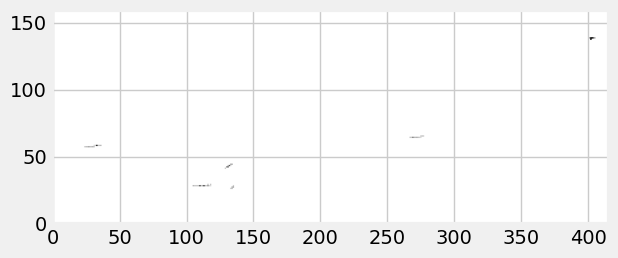

In [257]:
print("Event test before compression")
for event_test in events_test[:SELECTED_EVENTS]:
    show_image(event_test)

Event test after compression


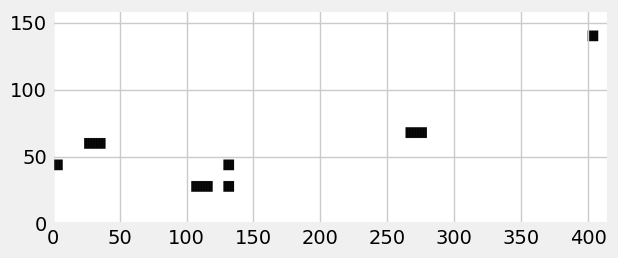

In [258]:
print("Event test after compression")
for event_test in decompressed_events[:SELECTED_EVENTS]:
    show_image(event_test)

<h2>Event compression statistics<h2>

In [259]:
# hit count in original events
n_hits_total = 0
for event_test in events_test[:SELECTED_EVENTS]:
    print(np.unique(event_test.det_ids))
    n_hits_total += len(event_test)
    
print(f"Selected events have hits: {n_hits_total}")

[303042564 303042568 303042572 ... 353335300 353338372 353339396]
Selected events have hits: 24791


In [260]:
# hit count in original events
n_hits_total_vq = 0
for decomp_event_test in decompressed_events[:SELECTED_EVENTS]:
    # print(np.unique(decomp_event_test.det_ids))
    # print([len(hit) for hit in decomp_event_test.hits])
    n_hits_total_vq += len(decomp_event_test)
    
print(f"Decompressed events have hits: {n_hits_total_vq}")

Decompressed events have hits: 540928


In [261]:
events_test[0].hits[0].adcs

array([153,  47,  65,  66,  92,  64,  67,  80,  55,  38,  55, 236,  58,
        59,  70,  75,  56,  56,  55,  62, 189,  61,  85, 192,  67,  51,
       106,  54,  42,  39,  58,  59, 111, 156,  51, 169,  49,  41,  82,
        70,  71,  86,  89,  51,  58,  58, 126,  74,  69,  80,  63,  52,
        38,  48,  60,  53, 106, 255, 255, 255, 182,  81], dtype=uint8)

In [262]:
decompressed_events[0].hits[0].adcs

array([0.4504451 , 0.45049056, 0.4504451 , 0.45049056, 0.4504451 ,
       0.45049056, 0.4504451 , 0.45049056, 0.43988353, 0.4668678 ,
       0.43988353, 0.4668678 , 0.43988353, 0.4668678 , 0.43988353,
       0.4668678 , 0.4504451 , 0.45049056, 0.4504451 , 0.45049056,
       0.4504451 , 0.45049056, 0.4504451 , 0.45049056, 0.43988353,
       0.4668678 , 0.43988353, 0.4668678 , 0.43988353, 0.4668678 ,
       0.43988353, 0.4668678 , 0.4504451 , 0.45049056, 0.4504451 ,
       0.45049056, 0.4504451 , 0.45049056, 0.4504451 , 0.45049056,
       0.43988353, 0.4668678 , 0.43988353, 0.4668678 , 0.43988353,
       0.4668678 , 0.43988353, 0.4668678 , 0.4504451 , 0.45049056,
       0.4504451 , 0.45049056, 0.4504451 , 0.45049056, 0.4504451 ,
       0.45049056, 0.43988353, 0.4668678 , 0.43988353, 0.4668678 ,
       0.43988353, 0.4668678 , 0.43988353, 0.4668678 , 0.4504451 ,
       0.45049056, 0.4504451 , 0.45049056, 0.4504451 , 0.45049056,
       0.4504451 , 0.45049056, 0.43988353, 0.4668678 , 0.43988

<h1>VQ-VAE compression metrics</h1>

In [263]:
# for i in range(SELECTED_EVENTS):
#     event = events_test[i]
#     result = 
#         event,
#         decompressed_events[i]
#     )
#     print(f"Event ID = {event.id_}")
#     print(result)

# Showing test vs reconstructed events
event_hits_metrics(
   events_test[:SELECTED_EVENTS],
   decompressed_events[:SELECTED_EVENTS] 
)

{'rmse': 111.99507784245475,
 'mae': 93.72039031982422,
 'mismatch_ratio': 1.0,
 'reco_precision_recall': (0.04583049869853289, 1.0)}

Average Perplexity (code books per epochs) values over epochs


/tmp/ipykernel_3521379/2342257702.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


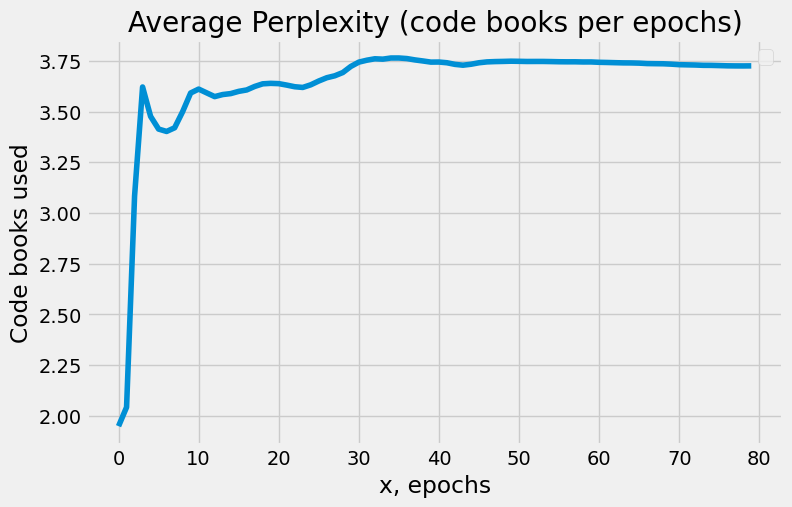

In [264]:
# perplexity
plot_metric_results(
    perplexity_values, 
    list(range(num_epochs)), 
    "Code books used", 
    "Average Perplexity (code books per epochs)",
    "x, epochs"
)